In [2]:
from IPython.display import Image

# 梯度分解
对于任意KL估计器，其**期望梯度**可以<font color='red'>分解为两部分</font>：

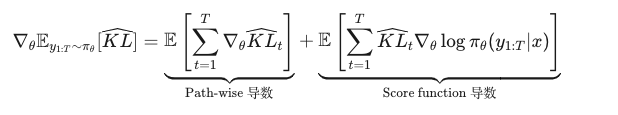

In [3]:
Image(filename='estimator.png')

## 基本定义
Score Function（得分函数/分数函数）是**概率分布**<font color='red'>对数似然</font><font color='blue'>关于参数</font>的梯度：

$s_\theta(y) = ∇_{\theta}logπ_\theta(y) =\frac{∇_\thetaπ_\theta(y)}{π_\theta(y)} $


| 名称                                 | 含义                            |
| ---------------------------------- | ----------------------------- |
| π_θ(y)                    | 策略/模型在参数 $\theta$ 下输出 $y$ 的<font color='red'>概率</font> |
| logπ_θ(y)               | <font color='red'>对数似然</font>（log-likelihood）          |
|∇_θlogπ_θ(y) | 对数似然<font color='blue'>对参数的梯度 </font>                   |


# 为什么叫"得分"？

In [ ]:
直观理解：
┌─────────────────────────────────────────────┐
│  如果模型对某个输出 y 很"自信"（概率高）      │
│  → log π_θ(y) 接近 0                        │
│  → 稍微调整参数，对数概率变化不大              │
│  → score 较小                               │
│                                             │
│  如果模型对某个输出 y 很"不确定"（概率低）     │
│  → log π_θ(y) 很负                          │
│  → 稍微调整参数，对数概率可能变化很大           │
│  → score 较大                               │
│                                             │
│  Score = "参数空间中的敏感度/敏感度方向"        │
└─────────────────────────────────────────────┘

## 核心概念
- $log\pi_\theta ≈ 0 $  当$\pi_\theta ≈ 0 $
- 这是因为log(1) = 0

### 例子1：抛硬币（二分类）
假设模型预测"正面"的概率为 p ，分析 $ score = \frac{∂logp}{∂θ} $

  


#### ∂logp 到底代表什么？



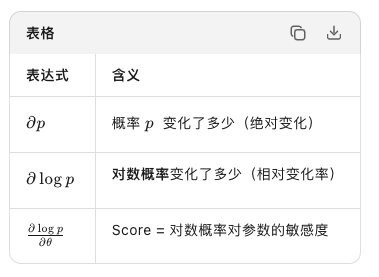

In [8]:
Image(filename='./∂logp.png')

In [ ]:
┌─────────────────────────────────────────────────────────┐
│  ∂p = 0.01                                              │
│  概率从 0.99 变到 1.00（绝对增加了0.01）                  │
│                                                         │
│  ∂log p = log(1.00) - log(0.99) = 0 - (-0.01005)       │
│         = 0.01005（对数尺度上的变化）                    │
│                                                         │
│  相对变化率：∂log p ≈ ∂p / p = 0.01 / 0.99 ≈ 0.0101     │
└─────────────────────────────────────────────────────────┘

#### ∂logp  衡量的是"相对变化"而非"绝对变化"：

| 场景                 | p 的变化   | logp 的变化           | 含义       |
| ------------------ | --------- | ---------------------- | -------- |
| p: 0.01 → 0.02 | +0.01（翻倍） | log 2 ≈ 0.693 | 很大！概率翻倍了 |
| p: 0.99 → 1.00 | +0.01（微增） | ≈ 0.01005      | 很小，接近饱和  |


#### 为什么用对数？

- 对数把 [0,1] 的极端差异"拉平"了                          
  -    <font color='red'>低概率区域的微小变化被放大</font> 
  -    高概率区域的微小变化被压缩 
  
- **这正是信息论中"信息量 = -log p"的直觉：**                  
  - 罕见事件（p小）→ 信息量大 → log变化大                    
  - 常见事件（p大）→ 信息量小 → log变化小 

In [ ]:
┌─────────────────────────────────────────────────────────┐
│  对数变换的"压缩"效果：                                   │
│                                                         │
│  p:    0.001  0.01   0.1    0.5    0.9    0.99   0.999 │
│  log p: -6.9   -4.6   -2.3   -0.69  -0.11  -0.01  -0.001│
│                                                         │
│  对数把 [0,1] 的极端差异"拉平"了                         │
│  → 低概率区域的微小变化被放大                            │
│  → 高概率区域的微小变化被压缩                            │
│                                                         │
│  这正是信息论中"信息量 = -log p"的直觉：                  │
│  罕见事件（p小）→ 信息量大 → log变化大                    │
│  常见事件（p大）→ 信息量小 → log变化小                    │
└─────────────────────────────────────────────────────────┘

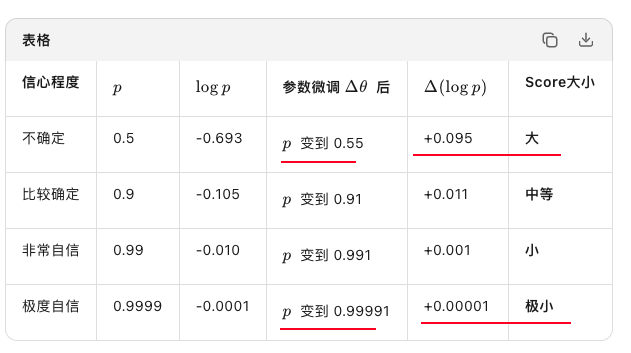

In [7]:
Image(filename='./log.png')

In [ ]:
概率接近1时，log概率已经"顶到天花板"了
    ↓
再调整参数，log概率也变化不了多少
    ↓
score = (log概率的变化)/(参数变化) → 很小

# 核心性质：期望为零


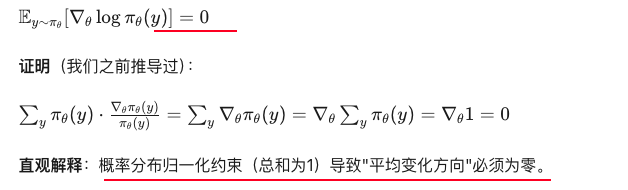

In [5]:
Image(filename='./qiwang_0.png')

## <font color='red'>从数学表达式上看是为0，但是实际场景下真的为0吗？</font>

### 理论 vs 实际：两个不同的世界



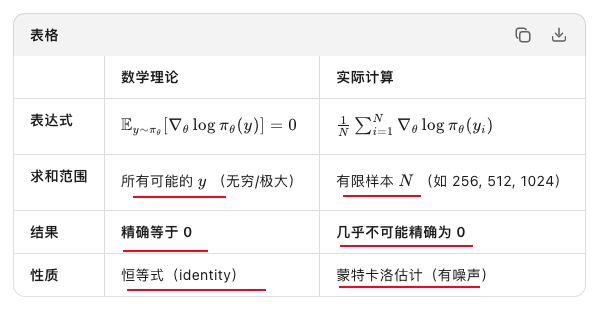

In [9]:
Image(filename='./com_0.png')

### 为什么实际中不为零？

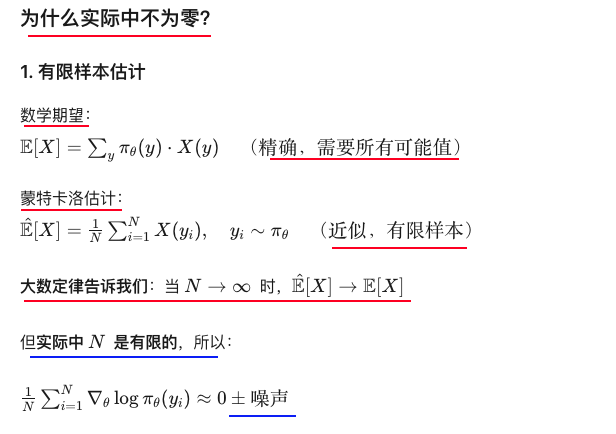

In [10]:
Image(filename='./why0_1.png')

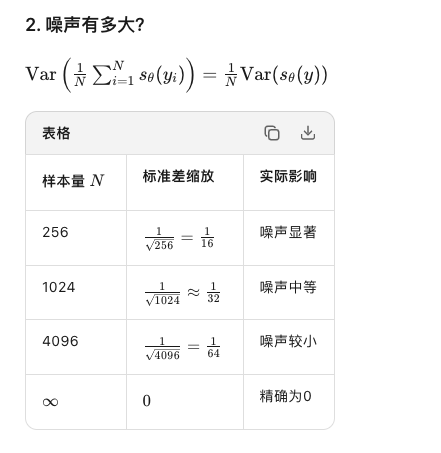

In [11]:
Image(filename='./why0_2.png')

### 这正是 K1-in-Loss 崩溃的原因！

#### K1-in-Loss 的梯度

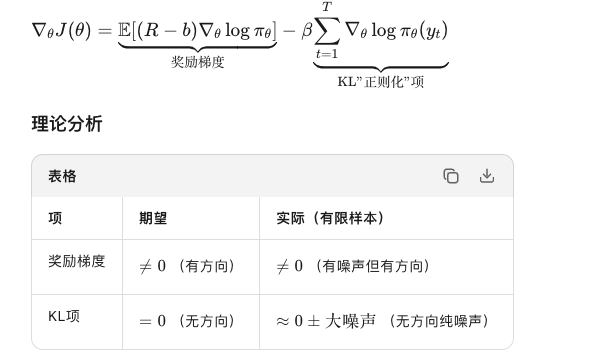

In [12]:
Image(filename='./k1-in-loss.png')

In [ ]:
训练初期：
┌─────────────────────────────────────────────┐
│  奖励梯度：→→→→→→→→→→→→→→→→→→→→→→→→→→→→→→→  │
│  KL项：    ～～～～～～～～～～～～～～～～～～～  │
│              （随机噪声，期望≈0）                │
│                                             │
│  总梯度：  →→→→→→→→→→→→→→→→→→→→→→→→→→→→→→→  │
│  （KL项只是增加了噪声，没有起到正则化作用）       │
└─────────────────────────────────────────────┘

训练后期（噪声累积）：
┌─────────────────────────────────────────────┐
│  奖励梯度：→→→→→→→→→→→→→→→→→→→→→→→→→→→→→→→  │
│  KL项：    ～～～～～～～～～～～～～～～～～～～  │
│  （方差累积，偶尔出现极端值）                   │
│                                             │
│  总梯度：  →→→→→→→→→→→→→→→→→→→→→→→→→→→→→→→  │
│            ↑ 偶尔：→→→→→→→→→→→→→→→→→→→→→→→→→→  │
│            （极端噪声导致参数跳变 → 崩溃）        │
└─────────────────────────────────────────────┘

### 关键区分：两种"期望为零"

| 类型         | 含义          | 实际影响               |
| ---------- | ----------- | ------------------ |
| **统计期望为零** | 无限样本下的数学恒等式 | 理论上 KL 正则化"不存在"    |
| **样本均值为零** | 有限样本的随机波动   | 增加了**方差/噪声**，导致不稳定 |

<font color='red'>论文中说"期望为零"指的是第一种（统计期望），但实际崩溃是由第二种（有限样本噪声）引起的。</font>


# Score Function 在机器学习中的核心作用

## 策略梯度（Policy Gradient）
这是 RL 中最关键的应用：

$\nabla_{\theta}J(\theta) = E_{y\~\pi_\theta}[R(y] ⋅ \nabla_{\theta}log\pi_{\theta}(y)$



## 为什么用 score function？
- 因为奖励 R(y)  通常不可微（比如数学题答案对错），<font color='red'>但 score function 让我们不需要知道 R  的具体形式，就能估计梯度！</font>

## 与 Fisher Information 的关系

## 在论文中的具体角色

| 论文                         | Score Function 的作用                                                                                   |
| -------------------------- | ---------------------------------------------------------------------------------------------------- |
| **A Comedy of Estimators** | K1-in-Loss 的梯度 = $\nabla_\theta \log \pi_\theta$，<font color='red'>期望为0，导致KL正则化失效 </font>                                     |
| **Entropy Mechanism**      | 协方差 $\text{Cov}(\log \pi_\theta, \Delta z) \propto \text{Cov}(\text{score}, \text{advantage})$ <font color='red'>驱动熵变化</font> |


# 直观类比
## 类比1：指南针

In [ ]:
Score Function = 参数空间中的"指南针"

        北（增加概率的方向）
           ↑
           │  ← score 指向这个方向
    西 ←───┼───→ 东
           │
           ↓
        南（减少概率的方向）

期望为零 = 所有方向的"拉力"平均抵消

## 类比2：投票

In [ ]:
每个样本 y 投一票：
- "参数应该往这个方向调"（score > 0）
- "参数应该往反方向调"（score < 0）

由于概率归一化，赞成票和反对票刚好抵消
→ 总票数（期望）= 0

# Score Function vs 普通梯度

|       | 普通梯度 $\nabla_\theta \pi_\theta(y)$ | Score Function $\nabla_\theta \log \pi_\theta(y)$ |
| ----- | ---------------------------------- | ------------------------------------------------- |
| 量纲    | 概率变化量                              | <font color='red'>相对变化率（无量纲） </font>                                       |
| 期望    | 不一定为零                              | <font color='red'>**恒为零** </font>                                          |
| 数值稳定性 | 概率接近0时梯度也接近0                       | 概率接近0时可能很大（敏感）                                    |
| **适用场景**  | 直接优化概率                             |<font color='red'> 采样估计、策略梯度   </font>                                      |

## 一句话总结
Score Function = 对数概率对参数的梯度 = $∇_θlogπ_θ(y)$ 。
- 它衡量"<font color='blue'>模型参数变化时，对数概率如何响应"</font>，期望恒为零（概率守恒），是策略梯度、变分推断等算法的核心工具。
- 在KL正则化分析中，K1-in-Loss 的梯度恰好等于 score function，<font color='blue'>期望为零意味着正则化项在平均意义上"消失"</font>——这是其失效的根本原因。